In [1]:
'''
We recommended that Boyan try to emulate spectroscopic completeness by matching 
the Khostovan+2026 COSMOS spec-z compilation to Cardinal galaxies using redshift, 
magnitude, and then color matched by percentile (i.e., so a real galaxy with a 10th
percentile real g-r color would map to a simulated galaxy with a 10th percentile simulated 
g-r color---this should help mitigate the distribution shift between real colors and 
simulated colors)
'''

'\nWe recommended that Boyan try to emulate spectroscopic completeness by matching \nthe Khostovan+2026 COSMOS spec-z compilation to Cardinal galaxies using redshift, \nmagnitude, and then color matched by percentile (i.e., so a real galaxy with a 10th\npercentile real g-r color would map to a simulated galaxy with a 10th percentile simulated \ng-r color---this should help mitigate the distribution shift between real colors and \nsimulated colors)\n'

In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import pyarrow as pa
import pyarrow.parquet as pq

/global/homes/b/boyanyin/.conda/envs/sompz/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
hdul = fits.open('Khostovan/specz_compilation_COSMOS_DR1.1_unique.fits')

data = hdul[1].data
header = hdul[0].header
#print(header)
print(data.names)

['Id_specz', 'Id_original', 'ra_original', 'dec_original', 'ra_corrected', 'dec_corrected', 'Priority', 'specz', 'flag', 'Confidence_level', 'survey', 'compilation_year', 'public_or_private', 'Id_COS20_Classic', 'ra_COS20_Classic', 'dec_COS20_Classic', 'Id_COS20_Farmer', 'ra_COS20_Farmer', 'dec_COS20_Farmer', 'Id_COSMOS25', 'ra_COSMOS25', 'dec_COSMOS25', 'Id_COSMOS15', 'ra_COSMOS15', 'dec_COSMOS15', 'Id_COSMOS09', 'ra_COSMOS09', 'dec_COSMOS09', 'photoz', 'photoz_type', 'GroupID', 'GroupSize']


## Check with Kohostovan paper

In [4]:
# Matching to paper listed numbers
#slightly smaller due to Sec 3.3. Mitigating Pair Galaxy Effects
print('A total of 266,284 unique sources make up the compilation, with 184,633 and 4338 sources having Qf = 3–4 and Qf = 13–14, respectively')
print('Tot unique source: ', np.shape(data['flag'])[0])
print('Qf = 3–4: ', np.sum((data['flag'] == 3) | (data['flag'] == 4)))
print('Qf = 13–14: ',np.sum((data['flag'] == 13) | (data['flag'] == 14)), '\n')
print('This corresponds to 133,916 unique sources (92% of all unique sources within COSMOS2020 coverage) with COSMOS2020 Classic photometry')
print('COSMOS2020 Classic: ', np.sum(data['Id_COS20_Classic']!= -999))

A total of 266,284 unique sources make up the compilation, with 184,633 and 4338 sources having Qf = 3–4 and Qf = 13–14, respectively
Tot unique source:  261975
Qf = 3–4:  183221
Qf = 13–14:  4328 

This corresponds to 133,916 unique sources (92% of all unique sources within COSMOS2020 coverage) with COSMOS2020 Classic photometry
COSMOS2020 Classic:  130065


In [5]:
#However, results shown
#below are restricted to SED fits for sources that have 𝑄 𝑓 = 3
#and 4, resulting in a total of 82,261 COSMOS2020 Classicmatched 0 < 𝑧 < 7.7 unique sources.
#Not right as the paper warn the star and AGN contamination of this selection

In [6]:
is_classic = (data['Id_COS20_Classic']!= -999)
goodz =  (data['flag'] == 3) | (data['flag'] == 4)
galaxy = data['photoz_type'] == 0

In [7]:
sel_classic = is_classic & goodz & galaxy

In [8]:
print(np.sum(sel_classic))
print(np.max(data['specz'][sel_classic]))
print(np.min(data['specz'][sel_classic]))

72182
7.677
-0.00013


In [9]:
is_farmer = (data['Id_COS20_Farmer']!= -999)
goodz =  (data['flag'] == 3) | (data['flag'] == 4)
galaxy = data['photoz_type'] == 0
sel_farmer = is_farmer & goodz & galaxy
print(np.sum(sel_farmer))

36719


In [10]:
spec_sample = pd.DataFrame(data[sel_classic])

In [11]:
## Matches are non-unique. Here I will only match to Classic
idx_multimatch = np.where(is_classic & is_farmer)[0]
print(idx_multimatch)
print(data['Id_COS20_Classic'][6601],  data['Id_COS20_Farmer'][6601])
print(data['ra_COS20_Classic'][6601],  data['ra_COS20_Farmer'][6601])
print(data['dec_COS20_Classic'][6601],  data['dec_COS20_Farmer'][6601])

[  6601   6887   6889 ... 121284 121297 121302]
135629 86094
149.90608416834624 149.90608301521897
1.5438157445575384 1.5437688087711101


## Match to COSMOS

In [12]:
import numpy as np
from astropy.table import Table
from astropy.io import fits

bands = ['CFHT_u', 'HSC_g', 'HSC_r', 'HSC_i', 'HSC_z', 'HSC_y',
         'UVISTA_Y', 'UVISTA_J', 'UVISTA_H', 'UVISTA_Ks']

suffixes = ['_FLUX_AUTO', '_MAG_AUTO', '_FLUXERR_AUTO', '_MAGERR_AUTO']

keep_columns = ['ID', 'ALPHA_J2000', 'DELTA_J2000']
for b in bands:
    for s in suffixes:
        keep_columns.append(f"{b}{s}")

with fits.open('COSMOS_photometry/COSMOS2020_CLASSIC_R1_v2.2_p3.fits') as hdul:
    existing_cols = [c for c in keep_columns if c in hdul[1].columns.names]
    
    full_table = Table(hdul[1].data)
    cosmos_classic = full_table[existing_cols]

cosmos_classic = cosmos_classic.to_pandas()

#### Play around with flux-mag conversion, generally the same

In [13]:
# zp = 23.9
# EQ for flux-mag conversion
# mag = zp - 2.5log10(flux)
flux_u = np.array(cosmos_classic['CFHT_u_FLUX_AUTO'])
mag_u = np.array(cosmos_classic['CFHT_u_MAG_AUTO'])
mag_u_computed = 23.9 - 2.5 * np.log10(flux_u)

#EQ of error propagation
#errm = |dm/df| * errf
#errm = -2.5/ln(10) * errf/f
fluxerr_u = np.array(cosmos_classic['CFHT_u_FLUXERR_AUTO'])
magerr_u = np.array(cosmos_classic['CFHT_u_MAGERR_AUTO'])
magerr_u_computed = 2.5/np.log(10) * fluxerr_u/flux_u

/tmp/ipykernel_600629/3920537140.py:6: RuntimeWarning: invalid value encountered in log10
  mag_u_computed = 23.9 - 2.5 * np.log10(flux_u)


#### Matching

In [14]:
df_z_classic = pd.merge(
    spec_sample, 
    cosmos_classic, 
    left_on='Id_COS20_Classic', 
    right_on='ID', 
    how='left'
)

In [15]:
df_z_classic 

,Id_specz,Id_original,ra_original,dec_original,ra_corrected,dec_corrected,Priority,specz,flag,Confidence_level,...,UVISTA_J_FLUXERR_AUTO,UVISTA_J_MAGERR_AUTO,UVISTA_H_FLUX_AUTO,UVISTA_H_MAG_AUTO,UVISTA_H_FLUXERR_AUTO,UVISTA_H_MAGERR_AUTO,UVISTA_Ks_FLUX_AUTO,UVISTA_Ks_MAG_AUTO,UVISTA_Ks_FLUXERR_AUTO,UVISTA_Ks_MAGERR_AUTO
0,53334,39627823496825154,150.85797,1.39143,150.85797,1.39143,1,1.14928,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,198676,39089837550134140,150.50909,1.39164,150.50909,1.39164,1,1.32009,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,157692,39089837550090008,149.66791,1.39147,149.66791,1.39147,1,0.85920,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,197941,39089837550111555,150.29494,1.39157,150.29494,1.39157,1,0.26658,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,198489,39089837550138236,150.56419,1.39168,150.56419,1.39168,1,1.29050,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72177,228074,39089837550078184,149.98062,3.07155,149.98062,3.07155,1,0.12338,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72178,132885,39089837499755747,149.86354,3.07150,149.86354,3.07150,1,1.32069,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72179,258475,39627859735611301,150.85170,3.07074,150.85170,3.07074,1,1.33890,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72180,127232,39089837487178450,149.46448,3.07061,149.46448,3.07061,1,1.10894,4,97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the col wanted

In [16]:
df_z_classic_final = pd.DataFrame({
    'i': df_z_classic['HSC_i_MAG_AUTO'],
    'u-g': df_z_classic['CFHT_u_MAG_AUTO'] - df_z_classic['HSC_g_MAG_AUTO'],
    'g-r': df_z_classic['HSC_g_MAG_AUTO'] - df_z_classic['HSC_r_MAG_AUTO'],
    'r-i': df_z_classic['HSC_r_MAG_AUTO'] - df_z_classic['HSC_i_MAG_AUTO'],
    'i-z': df_z_classic['HSC_i_MAG_AUTO'] - df_z_classic['HSC_z_MAG_AUTO'],
    'z-y': df_z_classic['HSC_z_MAG_AUTO'] - df_z_classic['HSC_y_MAG_AUTO'],
    'y-Y': df_z_classic['HSC_y_MAG_AUTO'] - df_z_classic['UVISTA_Y_MAG_AUTO'],
    'Y-J': df_z_classic['UVISTA_Y_MAG_AUTO'] - df_z_classic['UVISTA_J_MAG_AUTO'],
    'J-H': df_z_classic['UVISTA_J_MAG_AUTO'] - df_z_classic['UVISTA_H_MAG_AUTO'],
    'specz': df_z_classic['specz'],
    'ra': df_z_classic['ALPHA_J2000'], 
    'dec': df_z_classic['DELTA_J2000']
})

## Read Cardinal property

#### load Carinal Catalog

In [17]:
cardinal = '../job/data/hlwas_cosmos_260120_UM_2026_01_22_full.parquet'
df_cardinal = pd.read_parquet(cardinal)
df_cardinal = df_cardinal.reset_index(drop=True)

#print(df_cardinal.keys())

#### Convert to magnitude

In [18]:
#convert to magnitude
zp = 22.5
# EQ for flux-mag conversion
# mag = zp - 2.5log10(flux)
bands = ['_pgauss_LSST_u', '_pgauss_LSST_g', '_pgauss_LSST_r', 
         '_pgauss_LSST_i', '_pgauss_LSST_z', '_pgauss_LSST_y', 
         '_pgauss_Y', '_pgauss_J', '_pgauss_H']

for band in bands:
    df_cardinal.loc[:, 'mag' + band] = zp - 2.5 * np.log10(np.array(df_cardinal['flux' + band]))

#EQ of error propagation
#errm = |dm/df| * errf
#errm = 2.5/ln(10) * errf/f

for band in bands:
    df_cardinal.loc[:, 'mag_err' + band] = 2.5/np.log(10) * np.array(df_cardinal['flux_err' + band])/np.array(df_cardinal['flux' + band])
    

#### Get the col wanted

In [19]:
# i, u-g, g-r, r-i, i-z, z-y, y-Y, Y-J, J-H
df_cardinal_final = pd.DataFrame({
    'i': df_cardinal['mag_pgauss_LSST_i'],
    'u-g': df_cardinal['mag_pgauss_LSST_u'] - df_cardinal['mag_pgauss_LSST_g'],
    'g-r': df_cardinal['mag_pgauss_LSST_g'] - df_cardinal['mag_pgauss_LSST_r'],
    'r-i': df_cardinal['mag_pgauss_LSST_r'] - df_cardinal['mag_pgauss_LSST_i'],
    'i-z': df_cardinal['mag_pgauss_LSST_i'] - df_cardinal['mag_pgauss_LSST_z'],
    'z-y': df_cardinal['mag_pgauss_LSST_z'] - df_cardinal['mag_pgauss_LSST_y'],
    'y-Y': df_cardinal['mag_pgauss_LSST_y'] - df_cardinal['mag_pgauss_Y'],
    'Y-J': df_cardinal['mag_pgauss_Y'] - df_cardinal['mag_pgauss_J'],
    'J-H': df_cardinal['mag_pgauss_J'] - df_cardinal['mag_pgauss_H'],
    'specz': df_cardinal['specz'],
    'ra': df_cardinal['ra'],
    'dec': df_cardinal['dec'],
    'ID': df_cardinal['ID']
})

In [20]:
print('Before remove inf and nan photometry: ', len(df_z_classic_final), len(df_cardinal_final))
df_z_classic_final = df_z_classic_final.replace([np.inf, -np.inf], np.nan)
df_cardinal_final = df_cardinal_final.replace([np.inf, -np.inf], np.nan)

match_cols = ['specz', 'i', 'u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H']
df_z_classic_final = df_z_classic_final.dropna(subset=match_cols).reset_index(drop=True)
df_cardinal_final = df_cardinal_final.dropna(subset=match_cols).reset_index(drop=True)
print('After remove inf and nan photometry: ', len(df_z_classic_final), len(df_cardinal_final))


Before remove inf and nan photometry:  72182 2023037
After remove inf and nan photometry:  43465 2023037


## Plot properties

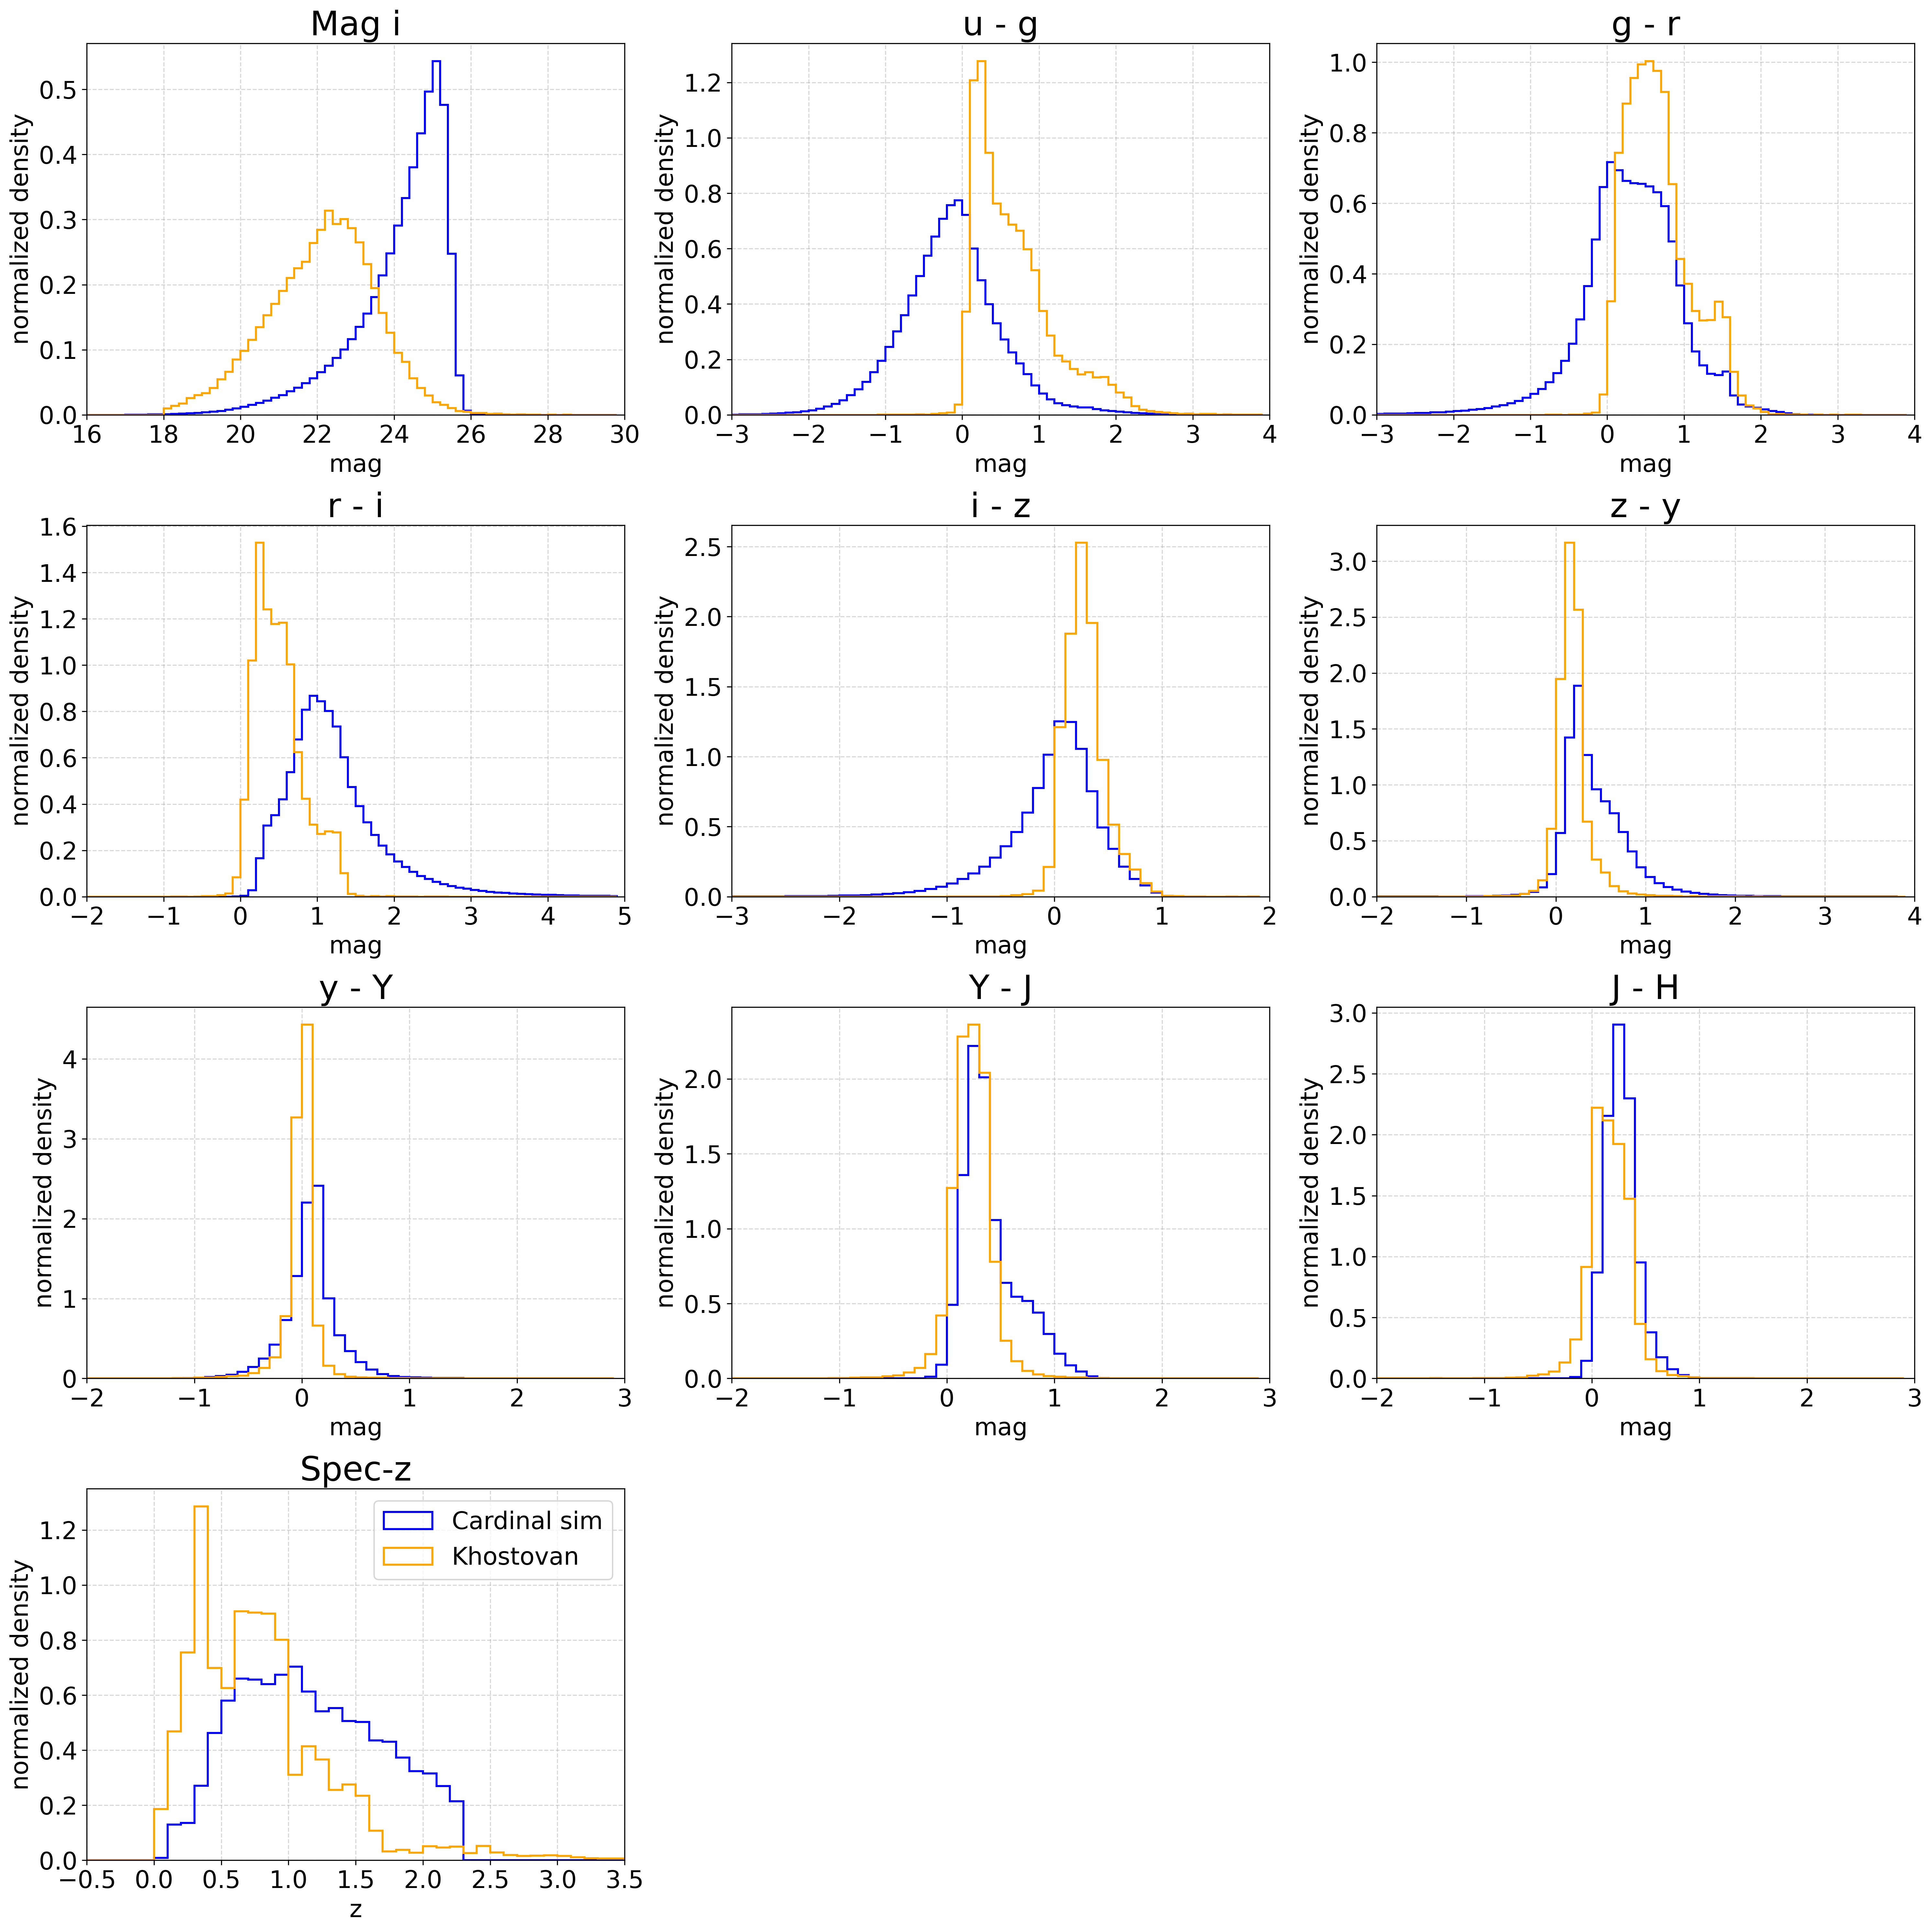

In [21]:
mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 5, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-3, 2, 0.1),    'xlim': (-3, 2),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 
    
    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim')
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan')
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Prematch_comparison_Classic_full.png')
plt.show()

## Percentile Matching

#### Jeff: By matching percentiles you will remove the main effects of the differences in the passbands, as long as the filters aren’t totally different.

In [22]:
from sklearn.neighbors import NearestNeighbors

In [23]:
feature_cols = ['specz', 'i']
color_cols = ['u-g', 'g-r', 'r-i', 'i-z', 'z-y', 'y-Y', 'Y-J', 'J-H']
all_cols = feature_cols + color_cols

cardinal_min = df_cardinal_final[feature_cols].min()
cardinal_max = df_cardinal_final[feature_cols].max()

classic_min = df_cardinal_final[feature_cols].min()
classic_min['i'] = 18 #Otherwise it is 13 which is too small and lead to weighting inproportionate
classic_max = df_cardinal_final[feature_cols].max()


classic_features = (df_z_classic_final[feature_cols] - classic_min) / (classic_max - classic_min)
cardinal_features = (df_cardinal_final[feature_cols] - classic_min) / (classic_max - classic_min)

classic_percentiles = pd.DataFrame(index=df_z_classic_final.index)
cardinal_percentiles = pd.DataFrame(index=df_cardinal_final.index)

for col in color_cols:
    classic_ranks = df_z_classic_final[col].rank(method='average')
    classic_percentiles[col] = (classic_ranks - 1) / (len(df_z_classic_final) - 1)
    
    cardinal_ranks = df_cardinal_final[col].rank(method='average')
    cardinal_percentiles[col] = (cardinal_ranks - 1) / (len(df_cardinal_final) - 1)


classic_combined = pd.concat([classic_features, classic_percentiles], axis=1)
cardinal_combined = pd.concat([cardinal_features, cardinal_percentiles], axis=1)

std_color = np.std(classic_percentiles['u-g'])
# Downweigh the color features so all color = mag i = redshift in weight
color_weight = 1.0 / np.sqrt(len(color_cols)) 

for col in color_cols:
    classic_combined[col] = classic_combined[col] * color_weight
    cardinal_combined[col] = cardinal_combined[col] * color_weight

# Reweigh the color features so all color = mag i = redshift in weight
for col in feature_cols:
    #classic_mean = np.mean(classic_combined[col])
    #classic_combined[col] = classic_combined[col] / classic_mean * 0.5
    #cardinal_combined[col] = cardinal_combined[col] / classic_mean * 0.5
    classic_std = np.std(classic_combined[col])
    classic_combined[col] = classic_combined[col] / classic_std * std_color
    cardinal_combined[col] = cardinal_combined[col] / classic_std * std_color

In [24]:
print('Now z, mag i, all color, contribute equally in matching: ')
print(np.std(classic_combined['i'])**2)
print(np.std(classic_combined['specz'])**2)
print(np.std(classic_combined['u-g'])**2*8)
print('Std of distance: ')
print((np.std(classic_combined['i'])**2*3)**(1/2))

Now z, mag i, all color, contribute equally in matching: 
0.08333716791653903
0.08333716791653903
0.08333716791653899
Std of distance: 
0.5000115036172839


## Plotting the feature and percentile for matching
#### z, mag i, all color, contribute equally in matching

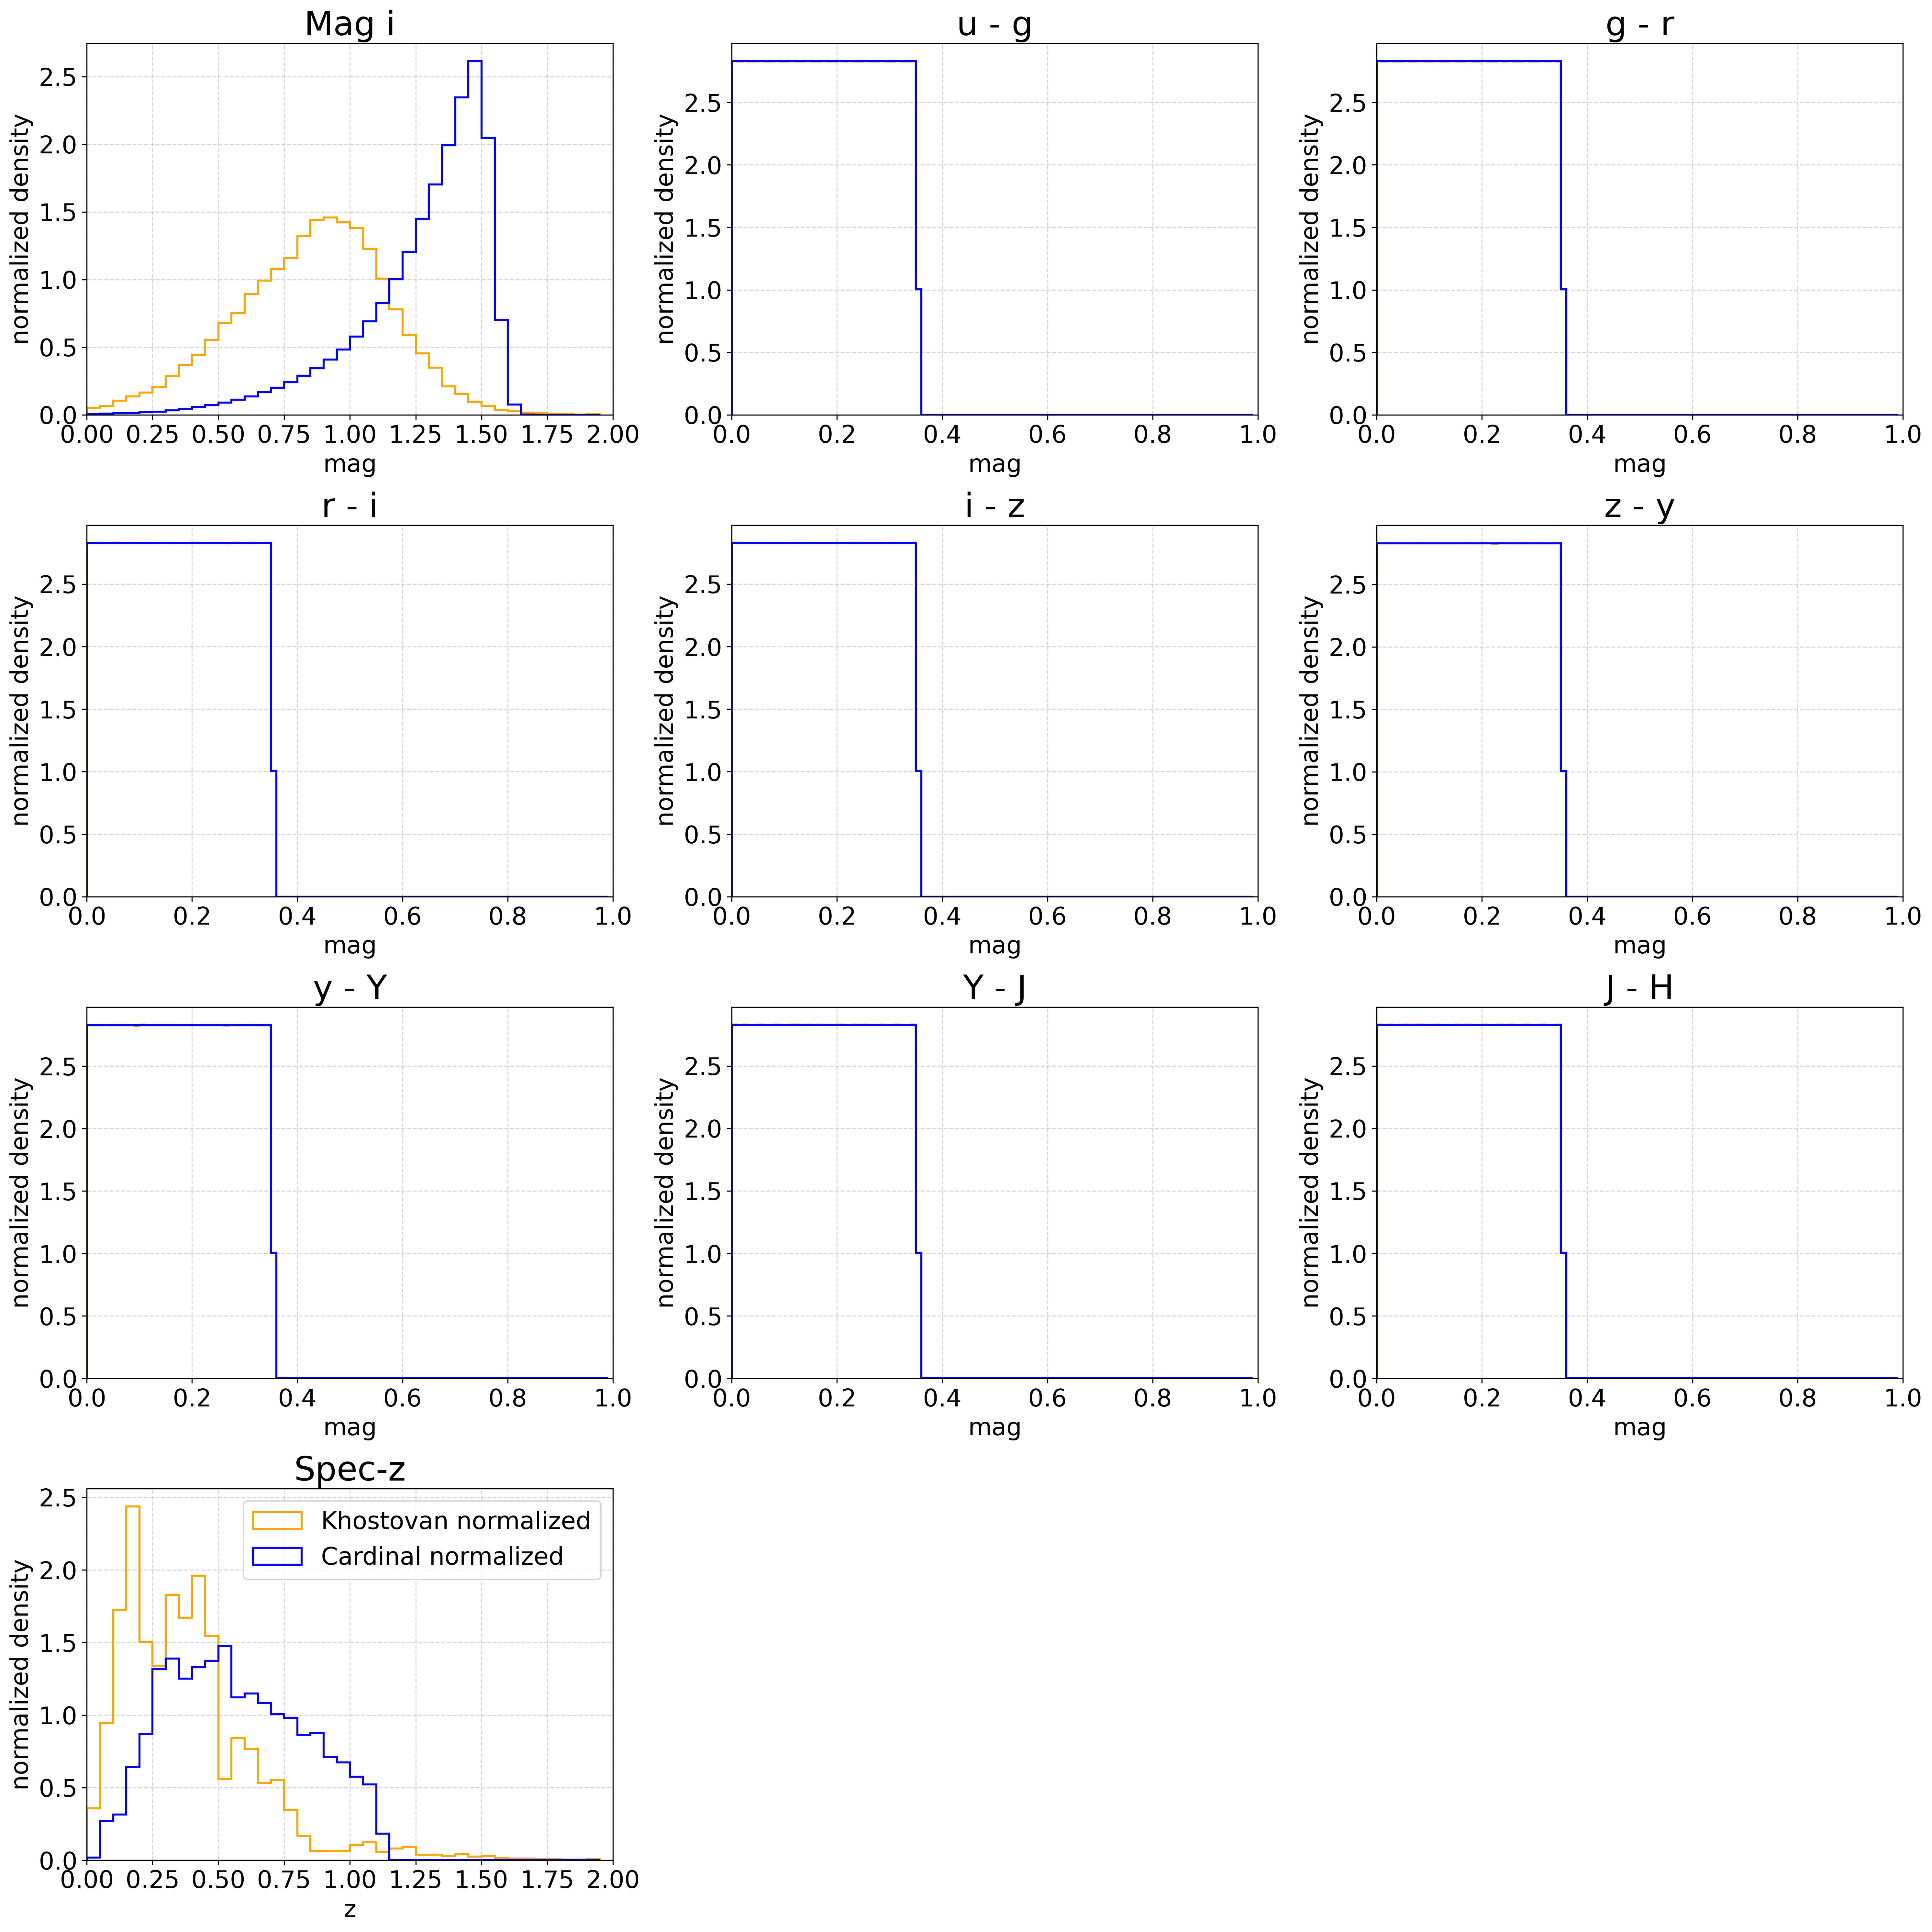

In [25]:
import matplotlib.pyplot as plt
import numpy as np

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(0,2,0.05),   'xlim': (0,2),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(0,1,0.01),    'xlim': (0,1),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(0,2,0.05),  'xlim': (0,2),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(classic_combined[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan normalized', alpha = 1)
    plt.hist(cardinal_combined[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal normalized', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.show()

### KNN

In [26]:
k_neighbors = 1000
max_distance = 0.2

nn = NearestNeighbors(n_neighbors=k_neighbors, algorithm='kd_tree', n_jobs=-1)
nn.fit(cardinal_combined.values)

distances, indices = nn.kneighbors(classic_combined.values)

used_indices = set()
final_unique_indices = []
unmatched_count = 0

print(f"Processing {len(classic_combined)} objects...")

for i in range(len(classic_combined)):
    assigned = False
    
    for j in range(k_neighbors):
        
        neighbor_idx = indices[i][j]
        distance = distances[i][j]
        
        if distance > max_distance:
            break
        if neighbor_idx not in used_indices:
            used_indices.add(neighbor_idx)
            final_unique_indices.append(neighbor_idx)
            assigned = True
            break
            
    if not assigned:
        unmatched_count += 1

matched_cardinal_indices = cardinal_combined.index[final_unique_indices]
df_cardinal_matched = df_cardinal_final.loc[matched_cardinal_indices].copy()

print(f"Total queries: {len(classic_combined)}")
print(f"Unique neighbors found: {len(final_unique_indices)}")

if unmatched_count > 0:
    print(f"Warning: {unmatched_count} queries exhausted all {k_neighbors} neighbors.")
    print(f"Action: Change k_neighbors to a higher number and re-run.")

Processing 43465 objects...
Total queries: 43465
Unique neighbors found: 20315
Action: Change k_neighbors to a higher number and re-run.


In [27]:
np.min(distances), np.max(distances), np.std(distances)

(0.03399243258262633, 2.4192562379364455, 0.10341832624725693)

#### Save matched file as parquet

In [28]:
df_cardinal_spec = df_cardinal[df_cardinal['ID'].isin(df_cardinal_matched['ID'])].reset_index(drop=True)

In [29]:
bands = ['_pgauss_LSST_u', '_pgauss_LSST_g', '_pgauss_LSST_r', 
         '_pgauss_LSST_i', '_pgauss_LSST_z', '_pgauss_LSST_y', 
         '_pgauss_Y', '_pgauss_J', '_pgauss_H']
flux_cols = [f"flux{band}" for band in bands]
flux_err_cols = [f"flux_err{band}" for band in bands] 
cols_to_keep = ['specz', 'ra', 'dec', 'ID'] + flux_cols + flux_err_cols
df_cardinal_spec = df_cardinal_spec[cols_to_keep]

In [30]:
data_matched= pa.Table.from_pandas(df_cardinal_spec)
pq.write_table(data_matched, '/pscratch/sd/b/boyanyin/Roman-SOMPZ/job/data/hlwas_cosmos_260120_UM_2026_01_22_classic_specmatch_full.parquet')

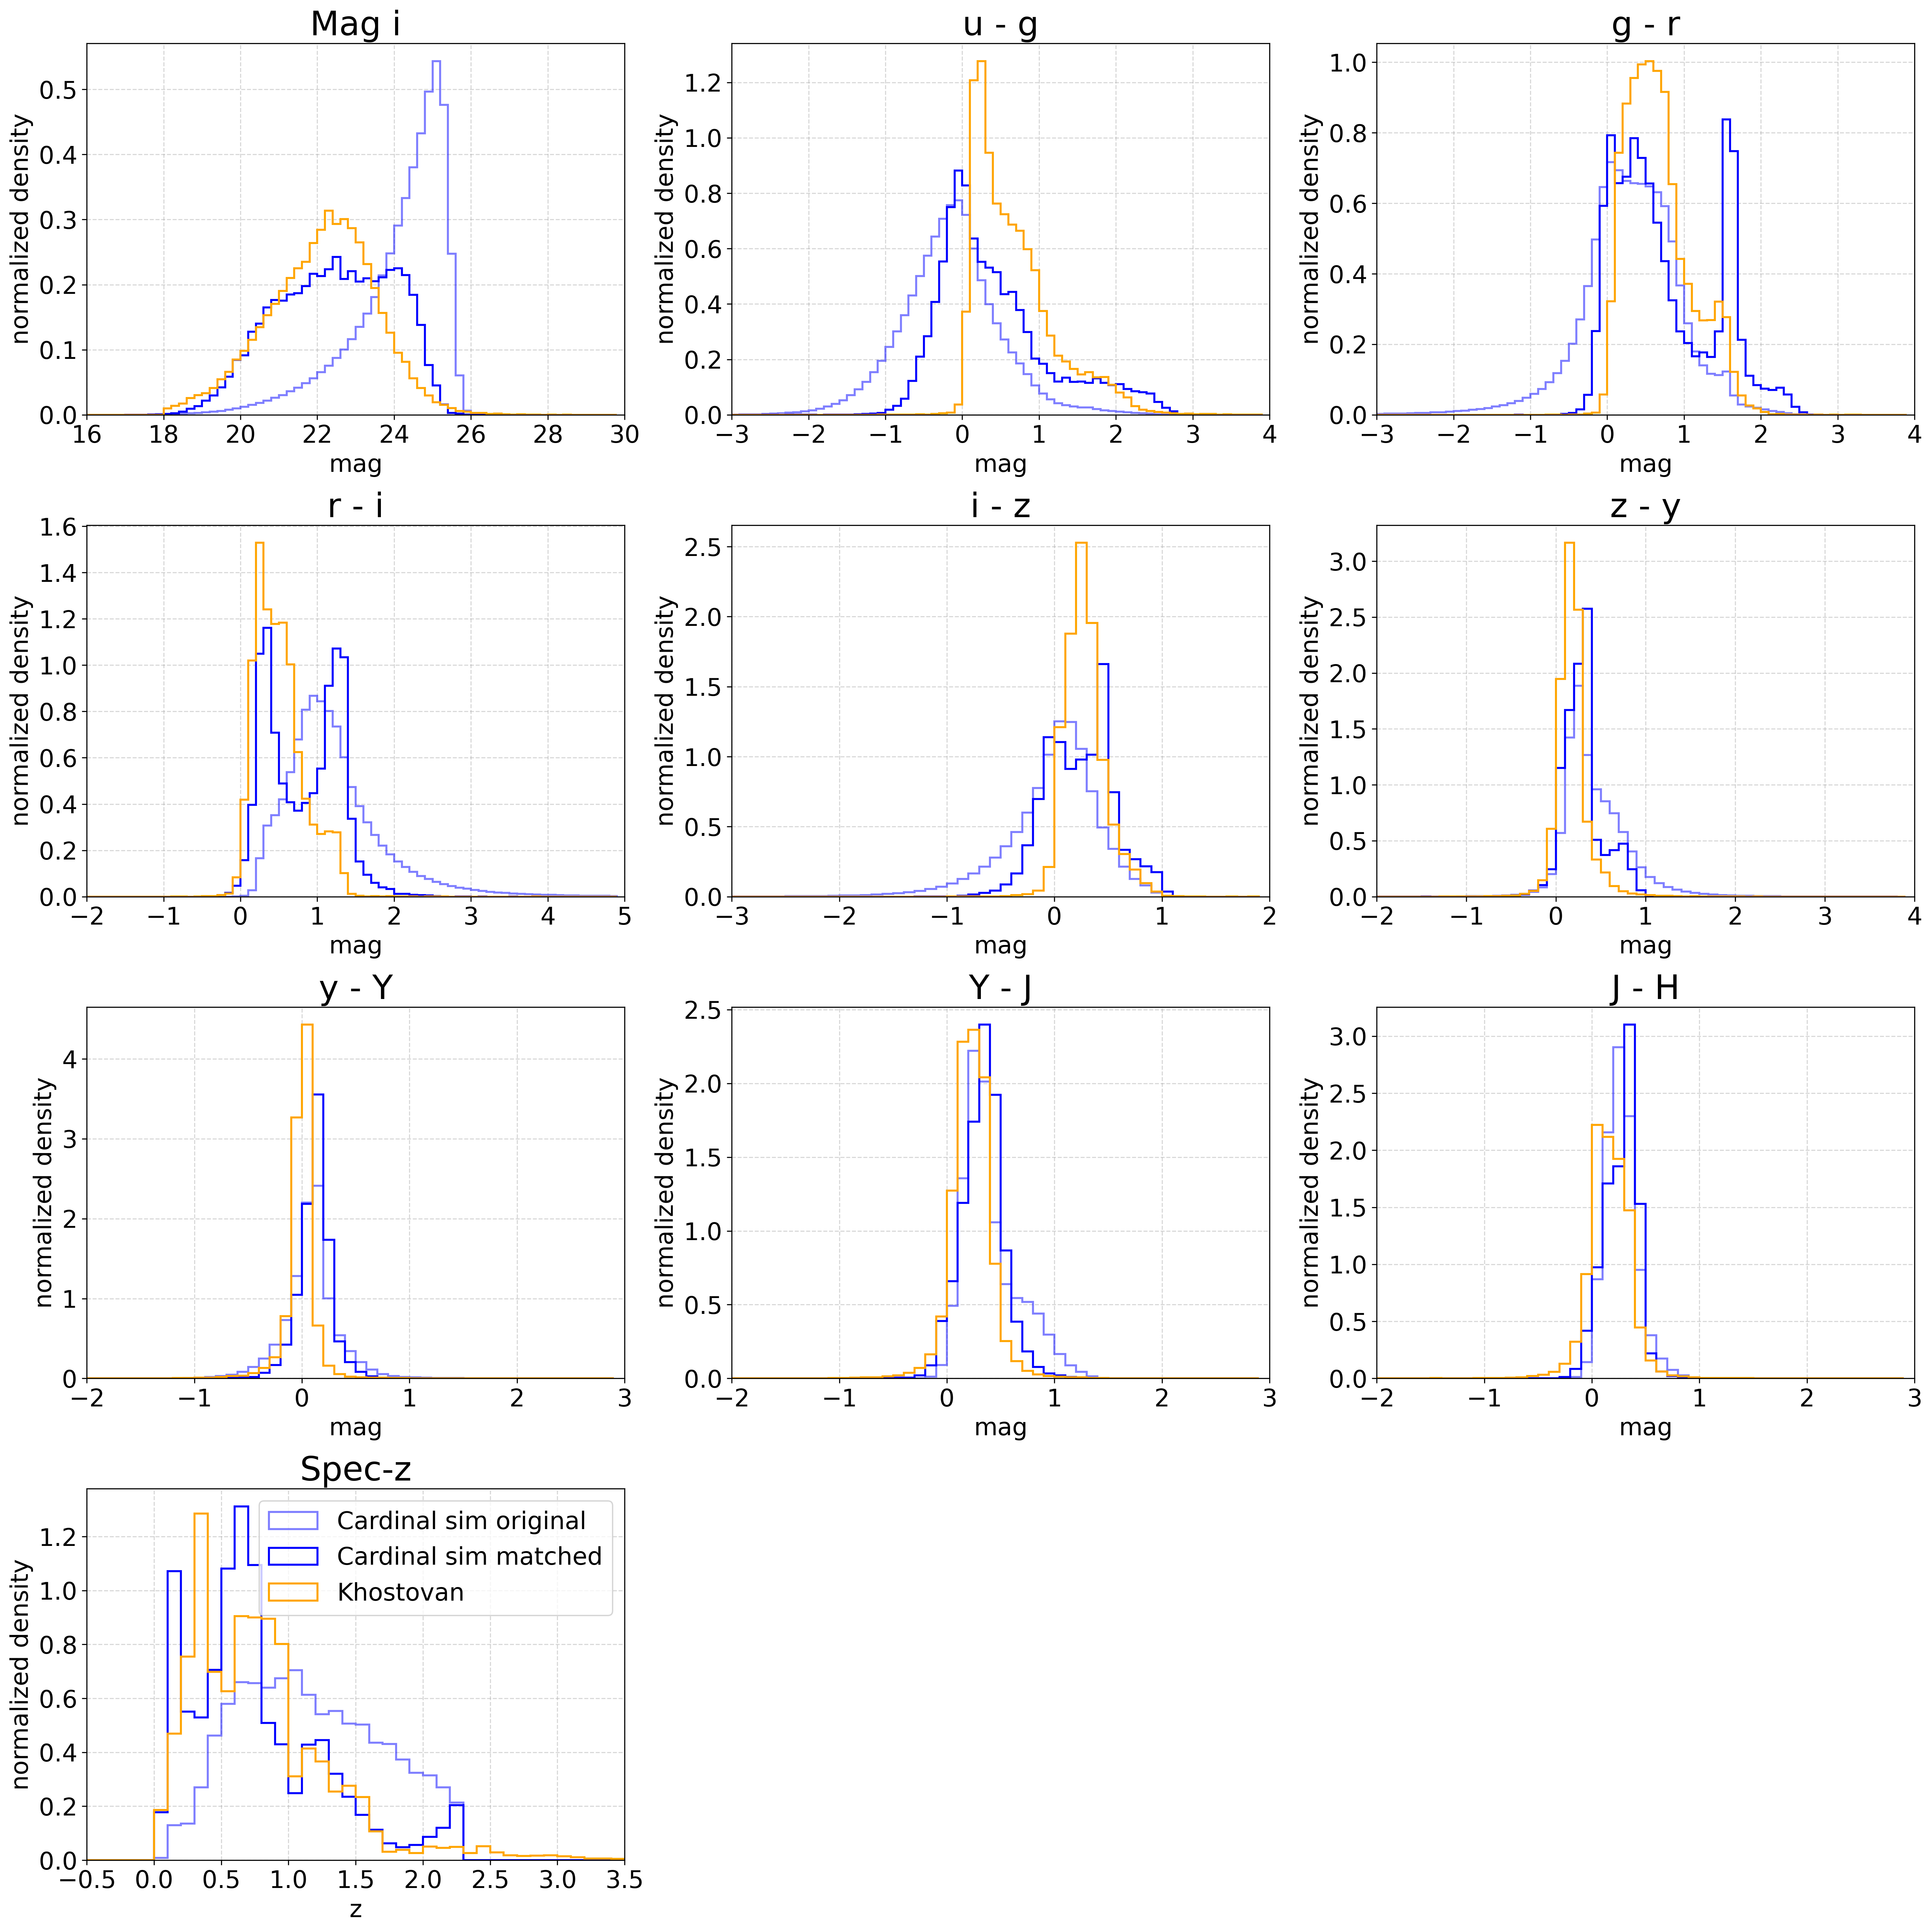

In [31]:
import matplotlib.pyplot as plt
import numpy as np

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-3, 4, 0.1),    'xlim': (-3, 4),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 5, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-3, 2, 0.1),    'xlim': (-3, 2),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim original', alpha = 0.5)
    plt.hist(df_cardinal_matched[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched', alpha = 1)
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Matched_comparison_Classic_percentile_color_full.png')
plt.show()

In [32]:
assert False

AssertionError: 

In [ ]:
## Test if high z frac of Cardinal will have a different color distribution
## Answer is No
highz_mask = df_cardinal_final['specz']<1.5
df_cardinal_final_lowz = df_cardinal_final[highz_mask]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-2, 7, 0.1),    'xlim': (-2, 7),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim original', alpha = 0.5)
    plt.hist(df_cardinal_final_lowz[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim lowz', alpha = 1)
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Prematched_comparison_Cardinal_lowz.png')
plt.show()

#### Or just possibly match by spec-z since the bands are so different

## z Matching

In [ ]:
match_cols = ['specz']

classic_vals = df_z_classic_final[match_cols] 
cardinal_vals = df_cardinal_final[match_cols]
k_neighbors = 1000
nn = NearestNeighbors(n_neighbors=k_neighbors, algorithm='kd_tree', n_jobs=-1)
nn.fit(cardinal_vals.values)

distances, indices = nn.kneighbors(classic_vals.values)

used_indices = set()
final_unique_indices = []
unmatched_count = 0

for i in range(len(classic_vals)):
    assigned = False
    
    for neighbor_idx in indices[i]:
        if neighbor_idx not in used_indices:
            used_indices.add(neighbor_idx)
            final_unique_indices.append(neighbor_idx)
            assigned = True
            break
            
    if not assigned:
        unmatched_count += 1
        final_unique_indices.append(indices[i][0]) 

matched_indices = df_cardinal_final.index[final_unique_indices]
df_cardinal_matched = df_cardinal_final.loc[matched_indices].copy()

unique_neighbors = np.unique(final_unique_indices)
print(f"Total queries: {len(final_unique_indices)}")
print(f"Unique neighbors found: {len(unique_neighbors)}")
if unmatched_count > 0:
    print(f"Warning: {unmatched_count} queries exhausted all {k_neighbors} neighbors. Increase K.")

In [ ]:

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-2, 7, 0.1),    'xlim': (-2, 7),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim original', alpha = 0.5)
    plt.hist(df_cardinal_matched[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched', alpha = 1)
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Matched_comparison_Classic_zonlymatch.png')
plt.show()

In [ ]:
highz_mask = df_cardinal_matched['specz']>2.0
df_cardinal_matched_highz = df_cardinal_matched[highz_mask]
lowz_mask = df_cardinal_matched['specz']<2.0
df_cardinal_matched_lowz = df_cardinal_matched[lowz_mask]

In [ ]:

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),        'xlabel': 'mag'},
    {'col': 'u-g',   'title': 'u - g',      'bins': np.arange(-2, 7, 0.1),    'xlim': (-2, 7),         'xlabel': 'mag'},
    {'col': 'g-r',   'title': 'g - r',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),         'xlabel': 'mag'},
    {'col': 'z-y',   'title': 'z - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),         'xlabel': 'mag'},
    {'col': 'y-Y',   'title': 'y - Y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'Y-J',   'title': 'Y - J',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),         'xlabel': 'mag'},
    {'col': 'J-H',   'title': 'J - H',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),         'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),     'xlabel': 'z'},
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_matched[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched', alpha = 0.5)
    plt.hist(df_cardinal_matched_highz[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Cardinal sim matched highz', alpha = 1)
    plt.hist(df_cardinal_matched_lowz[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched lowz', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Matched_comparison_Classic_zonlymatch_highvslowz.png')
plt.show()

## Previous approaches

In [ ]:
match_cols = ['i', 'u-i', 'g-i', 'r-i', 'i-z', 'i-y', 'i-Y', 'i-J', 'i-H', 'specz']

classic_vals = (df_z_classic_final[match_cols] - df_z_classic_final[match_cols].min()) / (df_z_classic_final[match_cols].max() - df_z_classic_final[match_cols].min())
cardinal_vals = (df_cardinal_final[match_cols] - df_cardinal_final[match_cols].min()) / (df_cardinal_final[match_cols].max() - df_cardinal_final[match_cols].min())

k_neighbors = 1000
nn = NearestNeighbors(n_neighbors=k_neighbors, algorithm='kd_tree', n_jobs=-1)
nn.fit(cardinal_vals.values)

distances, indices = nn.kneighbors(classic_vals.values)

used_indices = set()
final_unique_indices = []
unmatched_count = 0

for i in range(len(classic_vals)):
    assigned = False
    
    for neighbor_idx in indices[i]:
        if neighbor_idx not in used_indices:
            used_indices.add(neighbor_idx)
            final_unique_indices.append(neighbor_idx)
            assigned = True
            break
            
    if not assigned:
        unmatched_count += 1
        final_unique_indices.append(indices[i][0]) 

matched_indices = df_cardinal_final.index[final_unique_indices]
df_cardinal_matched = df_cardinal_final.loc[matched_indices].copy()

unique_neighbors = np.unique(final_unique_indices)
print(f"Total queries: {len(final_unique_indices)}")
print(f"Unique neighbors found: {len(unique_neighbors)}")
if unmatched_count > 0:
    print(f"Warning: {unmatched_count} queries exhausted all {k_neighbors} neighbors. Increase K.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),       'xlabel': 'mag'},
    {'col': 'u-i',   'title': 'u - i',      'bins': np.arange(-2, 7, 0.1),    'xlim': (-2, 7),        'xlabel': 'mag'},
    {'col': 'g-i',   'title': 'g - i',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),        'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),        'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),        'xlabel': 'mag'},
    {'col': 'i-y',   'title': 'i - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),        'xlabel': 'mag'},
    {'col': 'i-Y',   'title': 'i - Y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),        'xlabel': 'mag'},
    {'col': 'i-J',   'title': 'i - J',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),        'xlabel': 'mag'},
    {'col': 'i-H',   'title': 'i - H',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),        'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),       'xlabel': 'z'},
    #{'col': 'ra',    'title': 'RA',         'bins': np.arange(-0.5, 3, 0.05), 'xlim': (-0.5, 2.5),    'xlabel': 'deg'},
    #{'col': 'dec',   'title': 'DEC',        'bins': np.arange(83, 90, 0.05),  'xlim': (83.5, 89.5),   'xlabel': 'deg'}
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim original', alpha = 0.5)
    plt.hist(df_cardinal_matched[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched', alpha = 1)
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Matched_comparison_Classic_propertymatch.png')
plt.show()

In [ ]:
match_cols = ['specz', 'i', 'u-i', 'g-i', 'r-i', 'i-z', 'i-y', 'i-Y', 'i-J', 'i-H']

classic_percentiles = pd.DataFrame()
for col in match_cols:
    ranks = df_z_classic_final[col].rank(method='average')
    classic_percentiles[col] = (ranks - 1) / (len(df_z_classic_final.dropna(subset=[col])) - 1)

cardinal_percentiles = pd.DataFrame()
for col in match_cols:
    ranks = df_cardinal_final[col].rank(method='average')
    cardinal_percentiles[col] = (ranks - 1) / (len(df_cardinal_final.dropna(subset=[col])) - 1)

classic_percentiles = classic_percentiles.dropna()
cardinal_percentiles = cardinal_percentiles.dropna()


from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

match_cols = ['specz', 'i', 'u-i', 'g-i', 'r-i', 'i-z', 'i-y', 'i-Y', 'i-J', 'i-H']

classic_percentiles = pd.DataFrame()
for col in match_cols:
    ranks = df_z_classic_final[col].rank(method='average')
    classic_percentiles[col] = (ranks - 1) / (len(df_z_classic_final.dropna(subset=[col])) - 1)

cardinal_percentiles = pd.DataFrame()
for col in match_cols:
    ranks = df_cardinal_final[col].rank(method='average')
    cardinal_percentiles[col] = (ranks - 1) / (len(df_cardinal_final.dropna(subset=[col])) - 1)

classic_percentiles = classic_percentiles.dropna()
cardinal_percentiles = cardinal_percentiles.dropna()

#Neighbor finding
k_neighbors = 1000
nn = NearestNeighbors(n_neighbors=k_neighbors, algorithm='kd_tree', n_jobs=-1)
nn.fit(cardinal_percentiles[match_cols].values)

distances, indices = nn.kneighbors(classic_percentiles[match_cols].values)

used_indices = set()
final_unique_indices = []
unmatched_count = 0
print(len(classic_percentiles))
for i in range(len(classic_percentiles)):
    assigned = False
    
    for neighbor_idx in indices[i]:
        if neighbor_idx not in used_indices:
            used_indices.add(neighbor_idx)
            final_unique_indices.append(neighbor_idx)
            assigned = True
            break
            
    if not assigned:
        unmatched_count += 1
        final_unique_indices.append(indices[i][0]) 

matched_cardinal_indices = cardinal_percentiles.index[final_unique_indices]
df_cardinal_matched = df_cardinal_final.loc[matched_cardinal_indices].copy()

unique_neighbors = np.unique(final_unique_indices)
print(f"Total queries: {len(final_unique_indices)}")
print(f"Unique neighbors found: {len(unique_neighbors)}")

if unmatched_count > 0:
    print(f"Warning: {unmatched_count} queries exhausted all {k_neighbors} neighbors.")
    print(f"Action: Change k_neighbors to a higher number (e.g., 100 or 200) and re-run.")

In [ ]:
# 43465 df_z_classic_final
# 47499 df_z_cardinal_final

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mag_bins = np.arange(16, 29, 0.2)
color_bins = np.arange(-2, 5, 0.1)

plot_configs = [
    {'col': 'i',     'title': 'Mag i',      'bins': np.arange(16, 30, 0.2),   'xlim': (16, 30),       'xlabel': 'mag'},
    {'col': 'u-i',   'title': 'u - i',      'bins': np.arange(-2, 7, 0.1),    'xlim': (-2, 7),        'xlabel': 'mag'},
    {'col': 'g-i',   'title': 'g - i',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),        'xlabel': 'mag'},
    {'col': 'r-i',   'title': 'r - i',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),        'xlabel': 'mag'},
    {'col': 'i-z',   'title': 'i - z',      'bins': np.arange(-2, 3, 0.1),    'xlim': (-2, 3),        'xlabel': 'mag'},
    {'col': 'i-y',   'title': 'i - y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 4),        'xlabel': 'mag'},
    {'col': 'i-Y',   'title': 'i - Y',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),        'xlabel': 'mag'},
    {'col': 'i-J',   'title': 'i - J',      'bins': np.arange(-2, 4, 0.1),    'xlim': (-2, 5),        'xlabel': 'mag'},
    {'col': 'i-H',   'title': 'i - H',      'bins': np.arange(-2, 6, 0.1),    'xlim': (-2, 6),        'xlabel': 'mag'},
    {'col': 'specz', 'title': 'Spec-z',     'bins': np.arange(-0.5, 7, 0.1),  'xlim': (-0.5, 3.5),       'xlabel': 'z'},
    #{'col': 'ra',    'title': 'RA',         'bins': np.arange(-0.5, 3, 0.05), 'xlim': (-0.5, 2.5),    'xlabel': 'deg'},
    #{'col': 'dec',   'title': 'DEC',        'bins': np.arange(83, 90, 0.05),  'xlim': (83.5, 89.5),   'xlabel': 'deg'}
]

fig = plt.figure(figsize=(20, 20), dpi = 300)


for idx, config in enumerate(plot_configs, 1):
    plt.subplot(4, 3, idx) 

    plt.hist(df_cardinal_final[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim original', alpha = 0.5)
    plt.hist(df_cardinal_matched[config['col']], bins=config['bins'], histtype='step', color='blue', linewidth=1.5, density=True, label='Cardinal sim matched', alpha = 1)
    plt.hist(df_z_classic_final[config['col']], bins=config['bins'], histtype='step', color='orange', linewidth=1.5, density=True, label='Khostovan', alpha = 1)
    plt.title(config['title'], fontsize=25)
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel("normalized density", fontsize=18)
    plt.xlim(config['xlim'])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5) 
    
    if config['col'] == 'specz':
        plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('figs/Matched_comparison_Classic_percentilematch.png')
plt.show()